# Higer-Order Differential Equations and Systems of 1st-Order Differential Equations


In [1]:
# importing libraries
import numpy as np
import math
from matplotlib import pyplot as plt
from ipywidgets import interactive, fixed

# Definition of the IVP

In [2]:
# Define the IVP:

# Diff. Eqn.: y'' = f(x,y,y') = f(x,y0,y1)
# Define the IVP for Part (b)
def f(t, y):
    rhs = np.zeros((2, 1))
    # y[0] is y1, y[1] is y2
    rhs[0] = -4*y[0] - 2*y[1] + np.cos(t) + 4*np.sin(t)
    rhs[1] = 3*y[0] + y[1] - 3*np.sin(t)
    return rhs

# Initial Condition
y0 = np.array([[-0.4],[-0.6]])

In [3]:
# Explicit Runge-Kutta 4th-order Method
def erk4(t, w, h):
    s1 = f(t, w)
    s2 = f(t + 0.5*h, w + 0.5*h*s1)
    s3 = f(t + 0.5*h, w + 0.5*h*s2)
    s4 = f(t + h, w + h*s3)

    phi = (1/6)*(s1 + 2*s2 + 2*s3 + s4)
    return phi

In [4]:
# Time-stepping method to solve Initial Value Problems (IVPs)
# Use with f(t,y) to evaluate rhs of differential equation
# Input: interval endoints a and b,
#        initial condition y0,
#        number of steps n,
#        time-stepping flag s,
#                           s = 1:  Euler
#                           s = 2:  Explicit Trapezoid Method
#                           s = 4:  Runge-Kutta 4th-order
#
# Output: time steps t, approximate solution w
# Usage: euler(a,b,y_0,n)
# Example: euler(0,1,1,10)
def tstep(a, b, y0, n, mthd):
    m = np.size(y0)
    t = np.zeros(n+1)
    w = np.zeros((m, n+1))
    h = (b-a)/n
    t[0] = a
    w[:, 0:1] = y0

    for i in range(1, n+1):
        t[i] = t[i-1] + h
        if mthd == 1: # Euler
            w[:, i:i+1] = w[:, i-1:i] + h * f(t[i-1], w[:, i-1:i])
        elif mthd == 2: # Explicit Trapezoid
            k1 = f(t[i-1], w[:, i-1:i])
            k2 = f(t[i], w[:, i-1:i] + h * k1)
            w[:, i:i+1] = w[:, i-1:i] + (h/2) * (k1 + k2)
        elif mthd == 4: # RK4
            w[:, i:i+1] = w[:, i-1:i] + h * erk4(t[i-1], w[:, i-1:i], h)
    return t, w


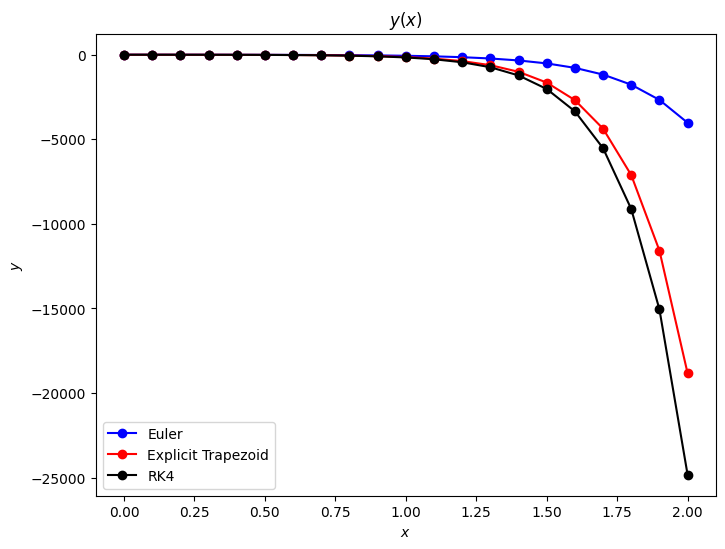

In [8]:
# Setup for Part (a)
#a, b = 0, 1
#h = 0.2
#n = int((b-a)/h)
#y0_a = np.array([[1.0], [1.0]]) # Initial conditions y1(0)=1, y2(0)=1

# Parameters for Part (b)
a, b = 0, 2
h = 0.1
n = int((b-a)/h)
y0_b = np.array([[0.0], [-1.0]]) # Initial conditions y1(0)=0, y2(0)=-1

# Exact solution function for comparison
#def exact_a(t):
   # y1 = (1/3)*(np.exp(5*t) - np.exp(-t)) + np.exp(2*t)
   # y2 = (1/3)*(np.exp(5*t) + 2*np.exp(-t)) + t**2 * np.exp(2*t)
   # return y1, y2

# Exact solution function for Part (b)
def exact_b(t):
    y1 = 2*np.exp(-t) - 2*np.exp(-2*t) + np.sin(t)
    y2 = -3*np.exp(-t) + 2*np.exp(-2*t)
    return y1, y2

[teu,weu]  = tstep(a,b,y0,n,1) # Euler
[ttr,wtr]  = tstep(a,b,y0,n,2) # Exp. Trap.
[trk,wrk]  = tstep(a,b,y0,n,4) # RK4

plt.figure(figsize=(8, 6))
plt.plot(teu,weu[0,:],'-o',color='blue',label = f'Euler')
plt.plot(ttr,wtr[0,:],'-o',color='red',label = f'Explicit Trapezoid')
plt.plot(trk,wrk[0,:],'-o',color='black',label = f'RK4')
plt.xlabel(f'$x$')
plt.ylabel(f'$y$')
plt.title(f'$y(x)$')

plt.legend();

In [9]:
import pandas as pd

# Run Solvers
[teu, weu] = tstep(a, b, y0_b, n, 1) # Euler
[ttr, wtr] = tstep(a, b, y0_b, n, 2) # Trap
[trk, wrk] = tstep(a, b, y0_b, n, 4) # RK4

# Calculate Exact Values and Errors
y1_ex, y2_ex = exact_b(trk)

# Create Master Table for Part (b)
master_data_b = {
    'ti': trk,
    'w1_RK4': wrk[0, :],
    'y1_Exact': y1_ex,
    'Err1_Euler': np.abs(y1_ex - weu[0, :]),
    'Err1_Trap': np.abs(y1_ex - wtr[0, :]),
    'Err1_RK4': np.abs(y1_ex - wrk[0, :]),
    'w2_RK4': wrk[1, :],
    'y2_Exact': y2_ex,
    'Err2_Euler': np.abs(y2_ex - weu[1, :]),
    'Err2_Trap': np.abs(y2_ex - wtr[1, :]),
    'Err2_RK4': np.abs(y2_ex - wrk[1, :])
}

df_b = pd.DataFrame(master_data_b)
pd.options.display.float_format = '{:.6e}'.format

print("Summary Results and Error Comparison (Part b, h=0.1):")
print(df_b.to_string(index=True))

Summary Results and Error Comparison (Part b, h=0.1):
             ti        w1_RK4     y1_Exact   Err1_Euler    Err1_Trap     Err1_RK4        w2_RK4      y2_Exact   Err2_Euler    Err2_Trap     Err2_RK4
0  0.000000e+00  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 -1.000000e+00 -1.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
1  1.000000e-01 -4.270742e-01 2.720467e-01 5.720467e-01 6.793383e-01 6.991210e-01 -1.636262e+00 -1.077051e+00 4.229493e-01 5.394051e-01 5.592111e-01
2  2.000000e-01 -1.225639e+00 4.954907e-01 1.310074e+00 1.655368e+00 1.721129e+00 -2.657787e+00 -1.115552e+00 1.117359e+00 1.475853e+00 1.542235e+00
3  3.000000e-01 -2.657518e+00 6.795334e-01 2.346191e+00 3.173240e+00 3.337052e+00 -4.315641e+00 -1.124831e+00 2.188294e+00 3.024951e+00 3.190810e+00
4  4.000000e-01 -5.158952e+00 8.314005e-01 3.875690e+00 5.628086e+00 5.990352e+00 -7.028397e+00 -1.112302e+00 3.801920e+00 5.549179e+00 5.916095e+00
5  5.000000e-01 -9.454713e+00 9.567280e-01 6.190921e

# Boundary Value Problems (BVP)
## The Linear Shooting Method

In [ ]:
# Apporximation solution using RK4
# parameters specific to current BVP
a     =
b     =
n     =

# Boundary Conditions:
alpha =
beta  =

# Initial Condition
yp0 = np.array([[],[]])

# Solve Nonhomogenous problem
[t,wp]  = tstep(a,b,yp0,n,4)

In [ ]:
# Initial Condition
yh0 = np.array([[],[]])

# Solve homogeneous IVP
[t,wh] = tstep(a,b,yh0,n,4)

In [ ]:
# Form linear combination of nonhomogeneous and homogeneous solution
s = (beta - wp[0,-1])/wh[0,-1]

w = wp + s*wh

y_exact =


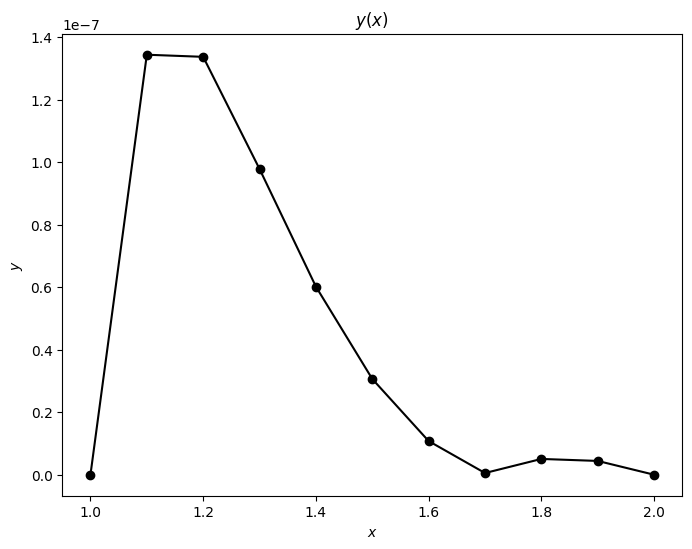

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(t,np.abs(y_exact - w[0,:]),'-o',color='black',label = f'RK4')
plt.xlabel(f'$x$')
plt.ylabel(f'$y$')
plt.title(f'$y(x)$');